In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from pathlib import Path
import logging
import yaml
from PIL import Image

In [ ]:
logger = logging.getLogger(__name__)

class YOLODataset(Dataset):
    """
    Arguments:
        img_dir (str): Path to directory with images (example: 'train/images').
        label_dir (str): Path to directory with labels (example 'train/labels').
        yaml_path (str, optional): Path to class_weights.yaml file.
        transform (callable, optional): Transformations for an image.
    """
    def __init__(self, img_dir, label_dir, yaml_path=None, transform=None):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform
        self.class_weights_dict = None

        if yaml_path:
            yaml_p = Path(yaml_path)
            if yaml_p.exists():
                with open(yaml_p, 'r') as f:
                    self.class_weights_dict = yaml.safe_load(f)
                logger.info(f"Loaded class weights from {yaml_path}")
            else:
                logger.warning(f"Weights file not found at {yaml_path}")

        self.image_files = sorted([
            f for f in self.img_dir.iterdir() 
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ])
        
        self.valid_files = []
        for img_file in self.image_files:
            label_file = self.label_dir / (img_file.stem + '.txt')
            if label_file.exists():
                self.valid_files.append(img_file)
            else:
                logger.warning(f"No label file for: {img_file.name}")

        logger.info(f"Found {len(self.valid_files)} valid pairs image/label.")

    def __len__(self):
        return len(self.valid_files)

    def get_class_weights(self):
        """Повертає словник ваг для передачі у Loss Function"""
        return self.class_weights_dict

    def __getitem__(self, idx):
        img_path = self.valid_files[idx]
        
        try:
            image = Image.open(img_path).convert("RGB")
            img_width, img_height = image.size
        except Exception as e:
            logger.error(f"Error opening image {img_path}: {e}")
            return torch.zeros(3, 224, 224), {}

        label_path = self.label_dir / (img_path.stem + '.txt')
        boxes = [] 
        
        try:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    
                    if len(parts) == 5:
                        boxes.append([float(p) for p in parts])
                    
                    elif len(parts) > 5:
                         logger.warning(f"Label format is not 5-digit YOLO at {label_path.name}")
                         boxes.append([float(p) for p in parts[:5]])
                    
            if not boxes:
                boxes = np.empty((0, 5), dtype=np.float32)
            else:
                boxes = np.array(boxes, dtype=np.float32)

        except Exception as e:
            logger.error(f"Error reading label file {label_path}: {e}")
            boxes = np.empty((0, 5), dtype=np.float32) 
            
        target = {}
        target["boxes"] = boxes 
        target["image_id"] = idx
        target["image_path"] = str(img_path)
        target["original_size"] = (img_width, img_height)

        if self.transform:
            image = self.transform(image) 

        return image, target

In [ ]:
class AlexNetYOLO(nn.Module):
    def __init__(self, num_classes=11, grid_size=7, num_bboxes=2):
        """
        AlexNet адаптована для Object Detection (YOLO-style head).
        
        Args:
            num_classes (int): Кількість класів. (11, оскільки макс. ID у вас 10).
            grid_size (int): Розмір сітки (S=7).
            num_bboxes (int): Кількість боксів на клітинку (B=2).
        """
        super(AlexNetYOLO, self).__init__()
        
        self.S = grid_size
        self.B = num_bboxes
        self.C = num_classes
        
        alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        self.features = alexnet.features
        
        self.avgpool = alexnet.avgpool 
        
        # S * S * (B * 5 + C)
        self.output_dim = self.S * self.S * (self.B * 5 + self.C)
        
        flatten_dim = 256 * 6 * 6
        
        self.detector = nn.Sequential(
            nn.Flatten(),
            
            nn.Dropout(p=0.7),
            nn.Linear(flatten_dim, 4096),
            nn.ReLU(inplace=True),
            
            nn.Dropout(p=0.7),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            
            nn.Linear(4096, self.output_dim)
        )
        
        self._initialize_head()

    def _initialize_head(self):
        for m in self.detector.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        x: [Batch, 3, 224, 224]
        return: [Batch, S, S, B*5 + C]
        """
        x = self.features(x)
        x = self.avgpool(x)
        
        x = self.detector(x)
        
        x = x.view(-1, self.S, self.S, (self.B * 5 + self.C))
        
        return x

In [ ]:
class YOLOAlexNetLoss(nn.Module):
    def __init__(self, S=7, B=2, C=11, class_weights_dict=None, device='cpu'):
        """
        Args:
            S (int): Розмір сітки (7x7).
            B (int): Кількість боксів на клітинку.
            C (int): Кількість класів. (Ставимо 11, бо макс ID = 10).
            class_weights_dict (dict): Словник з вагами {id: weight}.
        """
        super(YOLOAlexNetLoss, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.device = device
        
        self.lambda_coord = 5.0 
        self.lambda_noobj = 0.5  

        self.class_weights = torch.ones(C).to(device)
        
        if class_weights_dict:
            for class_id, weight in class_weights_dict.items():
                if class_id < C:
                    self.class_weights[int(class_id)] = weight
            
            print(f"Initialized Class Weights Tensor: {self.class_weights}")

    def forward(self, predictions, target_boxes):
        """
        predictions: [Batch, S, S, B*5 + C] - вихід нашої AlexNet
        target_boxes: List of Tensors (batch_size) - список боксів з датасету
                      Кожен елемент списку: [Num_objects, 5] -> (class_id, x, y, w, h)
        """
        
        batch_size = predictions.shape[0]
        target_tensor = torch.zeros_like(predictions).to(self.device)
        
        exists_box = torch.zeros(batch_size, self.S, self.S).to(self.device)

        for b_idx in range(batch_size):
            for box in target_boxes[b_idx]:
                class_id, x, y, w, h = box.tolist()
                class_id = int(class_id)

                i, j = int(self.S * y), int(self.S * x)
                
                x_cell, y_cell = self.S * x - j, self.S * y - i
                
                width_cell, height_cell = w * self.S, h * self.S

                if exists_box[b_idx, i, j] == 0:
                    exists_box[b_idx, i, j] = 1

                    target_tensor[b_idx, i, j, 0:5] = torch.tensor([x_cell, y_cell, width_cell, height_cell, 1.0])
                    if self.B > 1:
                        target_tensor[b_idx, i, j, 5:10] = torch.tensor([x_cell, y_cell, width_cell, height_cell, 1.0])
                    
                    if class_id < self.C:
                        cls_idx = self.B * 5 + class_id
                        target_tensor[b_idx, i, j, cls_idx] = 1.0
        
        predictions = predictions.reshape(-1, self.S, self.S, self.B * 5 + self.C)
    
        obj_mask = exists_box.unsqueeze(-1) 
        
        pred_coords = predictions[..., 0:4] 
        target_coords = target_tensor[..., 0:4]
        
        coord_loss = torch.sum(obj_mask * (pred_coords - target_coords) ** 2)

        pred_conf = predictions[..., 4:5]
        target_conf = target_tensor[..., 4:5] # Це одиниці
        
        obj_conf_loss = torch.sum(obj_mask * (pred_conf - target_conf) ** 2)

        noobj_mask = 1 - obj_mask
        
        noobj_conf_loss = torch.sum(noobj_mask * (pred_conf - target_conf) ** 2)

        
        pred_classes = predictions[..., self.B*5 :]
        target_classes = target_tensor[..., self.B*5 :]
        
        class_loss_mse = (pred_classes - target_classes) ** 2
        
        weighted_class_loss = class_loss_mse * self.class_weights
        
        class_loss = torch.sum(obj_mask * weighted_class_loss)

        total_loss = (
            self.lambda_coord * coord_loss +
            obj_conf_loss +
            self.lambda_noobj * noobj_conf_loss +
            class_loss
        )
        
        return total_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

NUM_CLASSES = 11 
GRID_SIZE = 7
NUM_BBOXES = 2
BATCH_SIZE = 2 

class_weights_dict = {
    3: 1.4484, 
    9: 0.2572, 
    10: 1.8922, 
    8: 0.3447, 
    7: 10.2017, 
    2: 1.5935, 
    4: 8.8543, 
    5: 9.8795, 
    1: 19.1542
}

model = AlexNetYOLO(
    num_classes=NUM_CLASSES, 
    grid_size=GRID_SIZE, 
    num_bboxes=NUM_BBOXES
).to(device)

print("Model initialized successfully.")

criterion = YOLOAlexNetLoss(
    S=GRID_SIZE, 
    B=NUM_BBOXES, 
    C=NUM_CLASSES, 
    class_weights_dict=class_weights_dict, 
    device=device
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("\n--- Starting Dummy Training Step ---")

dummy_images = torch.randn(BATCH_SIZE, 3, 224, 224).to(device)

target_img1 = torch.tensor([
    [9.0, 0.5, 0.5, 0.2, 0.4] 
]).to(device)

target_img2 = torch.tensor([
    [3.0, 0.2, 0.2, 0.1, 0.1],
    [1.0, 0.8, 0.7, 0.3, 0.3]
]).to(device)

dummy_targets = [target_img1, target_img2]

predictions = model(dummy_images)
print(f"Predictions shape: {predictions.shape}") 

loss = criterion(predictions, dummy_targets)
print(f"Loss value: {loss.item()}")

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Backward pass completed successfully.")

Running on: cuda
Model initialized successfully.
Initialized Class Weights Tensor: tensor([ 1.0000, 19.1542,  1.5935,  1.4484,  8.8543,  9.8795,  1.0000, 10.2017,
         0.3447,  0.2572,  1.8922], device='cuda:0')

--- Starting Dummy Training Step ---
Predictions shape: torch.Size([2, 7, 7, 21])
Loss value: 149.88021850585938
Backward pass completed successfully.


In [ ]:
DATA_ROOT = Path("data") 

DATA_YAML_PATH = DATA_ROOT / 'data.yaml'
WEIGHTS_YAML_PATH = DATA_ROOT / 'class_weights.yaml'

with open(DATA_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

num_classes = int(data_config['nc'])  

train_img_path = DATA_ROOT / 'train' / 'images'
train_label_path = DATA_ROOT / 'train' / 'labels'

print(f"Images path: {train_img_path}")
print(f"Labels path: {train_label_path}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # <--- ДОДАНО: Випадкове віддзеркалення
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = YOLODataset(
    img_dir=train_img_path,     # data/train/images
    label_dir=train_label_path, # data/train/labels
    yaml_path=WEIGHTS_YAML_PATH,# data/class_weights.yaml
    transform=transform
)

weights_dict = dataset.get_class_weights()

criterion = YOLOAlexNetLoss(
    S=7, 
    B=2, 
    C=num_classes, 
    class_weights_dict=weights_dict, 
    device=device
)

Images path: data\train\images
Labels path: data\train\labels
Initialized Class Weights Tensor: tensor([ 1.0000, 19.1542,  1.5935,  1.4484,  8.8543,  9.8795,  1.0000, 10.2017,
         0.3447,  0.2572,  1.8922], device='cuda:0')


In [ ]:
def collate_fn(batch):
    """
    Об'єднує список (image, target) у батч.
    """
    images = []
    target_boxes = []
    
    for img, tgt in batch:
        images.append(img)
        boxes = torch.tensor(tgt['boxes'], dtype=torch.float32)
        target_boxes.append(boxes)
        
    images = torch.stack(images, dim=0) # [Batch, 3, 224, 224]
    return images, target_boxes

In [ ]:
BATCH_SIZE = 16  # Якщо виникне помилка "CUDA out of memory", зменште до 8 або 4
LEARNING_RATE = 1e-4
EPOCHS = 20
NUM_WORKERS = 0  # На Windows краще ставити 0, щоб уникнути помилок мультипроцесингу

# --- 8. Створення DataLoader ---
train_loader = DataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn, # Обов'язково використовуємо нашу функцію
    drop_last=True         # Відкидаємо останній неповний батч, щоб не ламало статистику
)

print(f"DataLoader created. Batches per epoch: {len(train_loader)}")

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n=== Starting Training ===")
model.train() 

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        
        targets = [t.to(device) for t in targets]
        
        predictions = model(images) 
        
        loss = criterion(predictions, targets)
        
        optimizer.zero_grad() # Очищаємо старі градієнти
        loss.backward()       # Рахуємо нові градієнти
        optimizer.step()      # Оновлюємо ваги моделі
        
        epoch_loss += loss.item()
        
        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    avg_loss = epoch_loss / len(train_loader)
    print(f"--- Epoch {epoch+1} Finished. Avg Loss: {avg_loss:.4f} ---")
    
    if (epoch + 1) % 5 == 0:
        save_path = f"alexnet_yolo_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Checkpointed model saved to {save_path}")

print("Training complete.")

DataLoader created. Batches per epoch: 279

=== Starting Training ===
Epoch [1/20] | Batch [0/279] | Loss: 1414.4617
Epoch [1/20] | Batch [10/279] | Loss: 425.9935
Epoch [1/20] | Batch [20/279] | Loss: 409.8427
Epoch [1/20] | Batch [30/279] | Loss: 324.8496
Epoch [1/20] | Batch [40/279] | Loss: 217.4045
Epoch [1/20] | Batch [50/279] | Loss: 125.3398
Epoch [1/20] | Batch [60/279] | Loss: 200.4519
Epoch [1/20] | Batch [70/279] | Loss: 546.1067
Epoch [1/20] | Batch [80/279] | Loss: 272.4661
Epoch [1/20] | Batch [90/279] | Loss: 186.1712
Epoch [1/20] | Batch [100/279] | Loss: 117.2907
Epoch [1/20] | Batch [110/279] | Loss: 170.3920
Epoch [1/20] | Batch [120/279] | Loss: 212.5404
Epoch [1/20] | Batch [130/279] | Loss: 179.2616
Epoch [1/20] | Batch [140/279] | Loss: 264.6870
Epoch [1/20] | Batch [150/279] | Loss: 178.4321
Epoch [1/20] | Batch [160/279] | Loss: 224.3171
Epoch [1/20] | Batch [170/279] | Loss: 175.4232
Epoch [1/20] | Batch [180/279] | Loss: 91.4252
Epoch [1/20] | Batch [190/279

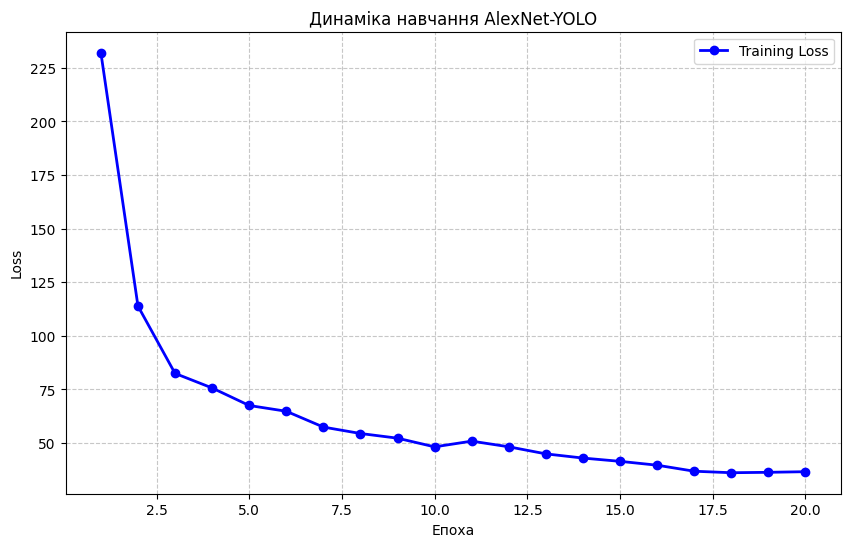

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

epochs = list(range(1, 21))
loss_history = [
    232.03, 113.89, 82.48, 75.69, 67.52, 
    64.83, 57.46, 54.46, 52.28, 48.23, 
    50.90, 48.26, 44.96, 43.01, 41.48, 
    39.68, 36.87, 36.17, 36.36, 36.65
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_history, 'b-o', linewidth=2, label='Training Loss')
plt.title('Динаміка навчання AlexNet-YOLO')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

На зображенні yt-false-0007_jpg.rf.18313335c49f9a236d9a7c3de4f86dbe.jpg об'єктів не знайдено (низький score).


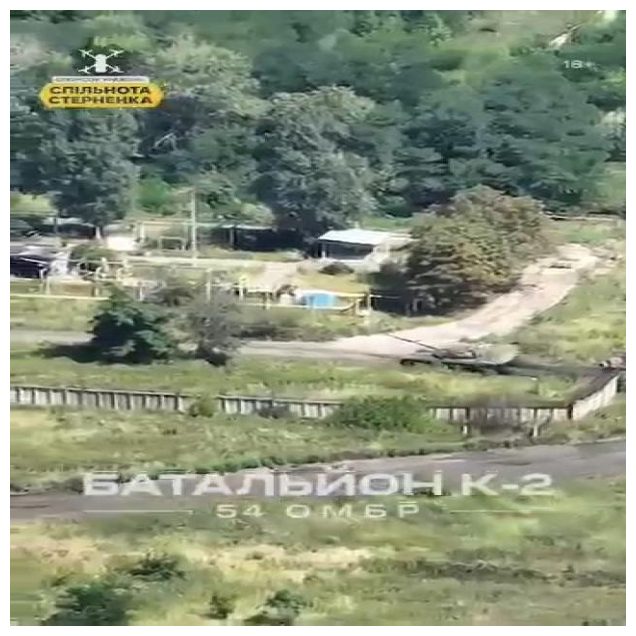

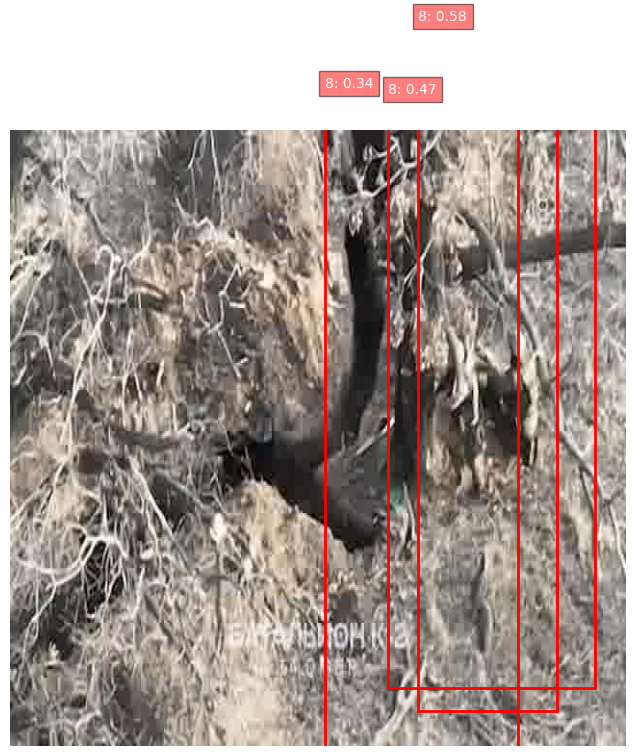

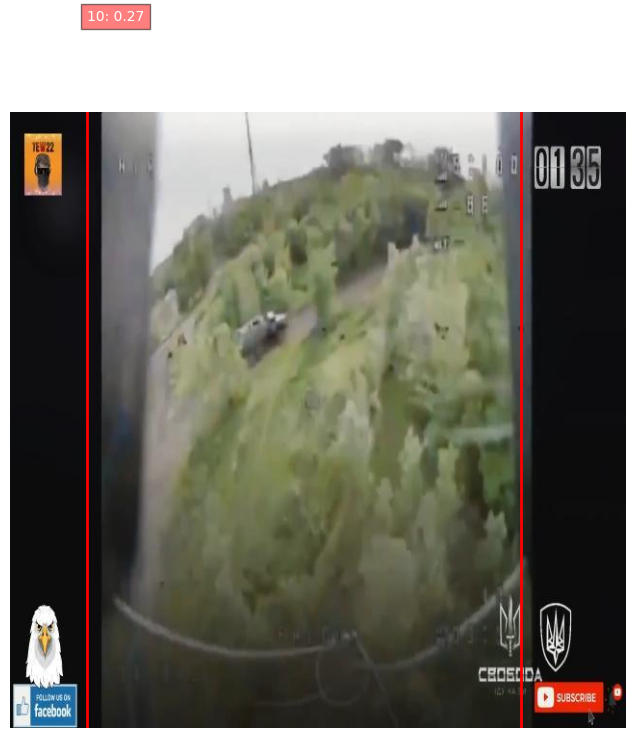

In [ ]:
def decode_prediction(prediction, S=7, B=2, num_classes=11, conf_thresh=0.3):
    """
    Перетворює тензор [S, S, B*5+C] у список боксів [x, y, w, h, class_id, score]
    """
    boxes = []
    # prediction: [7, 7, 21]
    
    for i in range(S):      # y-index
        for j in range(S):  # x-index
            cell = prediction[i, j]
            
            class_probs = cell[B*5:]
            class_conf, class_id = torch.max(class_probs, 0)
            
            for b in range(B):
                # Формат: [x, y, w, h, conf]
                start = b * 5
                conf = cell[start + 4]
                
                # Фінальна впевненість = впевненість бокса * ймовірність класу
                score = conf * class_conf
                
                if score > conf_thresh:
                    x_cell, y_cell, w_cell, h_cell = cell[start:start+4]
                    
                    # x_global = (x_cell + j) / S
                    x = (x_cell + j) / S
                    y = (y_cell + i) / S
                    w = w_cell # w вже нормалізована (0..1) відносно зображення (або w_cell/S - залежить від логіки Loss)
                    h = h_cell
                    
                    # Додаємо у список
                    boxes.append([x.item(), y.item(), w.item(), h.item(), class_id.item(), score.item()])
    
    return boxes

def show_inference(model, img_path, class_names=None):
    model.eval()
    
    try:
        img_raw = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"Не вдалося відкрити {img_path}")
        return

    img_tensor = transform(img_raw).unsqueeze(0).to(device) # [1, 3, 224, 224]
    
    with torch.no_grad():
        prediction = model(img_tensor) # [1, 7, 7, 21]
        prediction = prediction[0]     # [7, 7, 21]
        
    predicted_boxes = decode_prediction(prediction, conf_thresh=0.25)
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img_raw)
    
    width, height = img_raw.size
    
    if not predicted_boxes:
        print(f"На зображенні {Path(img_path).name} об'єктів не знайдено (низький score).")
    
    for box in predicted_boxes:
        x, y, w, h, cls, score = box
        
        # Переведення з YOLO (center x, center y, w, h) у кути (x1, y1)
        x1 = (x - w/2) * width
        y1 = (y - h/2) * height
        rect_w = w * width
        rect_h = h * height
        
        rect = patches.Rectangle((x1, y1), rect_w, rect_h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        label_text = f"Class {int(cls)}: {score:.2f}"
        if class_names and int(cls) < len(class_names):
             label_text = f"{class_names[int(cls)]}: {score:.2f}"
             
        ax.text(x1, y1 - 5, label_text, color='white', fontsize=10, 
                bbox=dict(facecolor='red', alpha=0.5))
        
    plt.axis('off')
    plt.show()

VAL_DIR = Path("data/valid/images") 
if not VAL_DIR.exists():
    VAL_DIR = Path("data/train/images") 

import random
all_images = list(VAL_DIR.glob("*.jpg"))
if all_images:
    test_images = random.sample(all_images, min(3, len(all_images)))
    class_names = [str(i) for i in range(11)] 
    
    for img_p in test_images:
        show_inference(model, img_p, class_names)
else:
    print("Зображення не знайдено.")

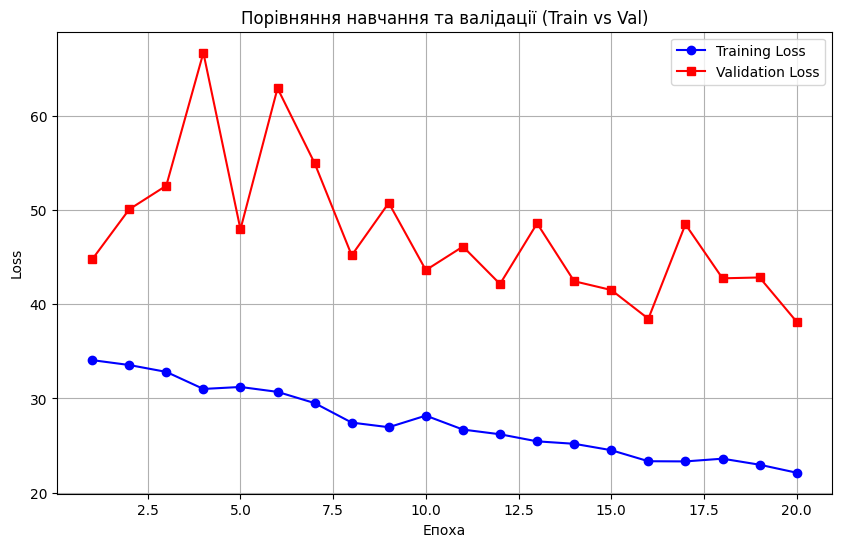

In [17]:
epochs = range(1, 21)
train_losses = [
    34.07, 33.55, 32.82, 31.01, 31.22, 30.70, 29.51, 27.44, 26.95, 28.18,
    26.70, 26.20, 25.45, 25.19, 24.51, 23.34, 23.32, 23.61, 22.97, 22.12
]
val_losses = [
    44.75, 50.07, 52.58, 66.69, 47.95, 62.92, 54.97, 45.19, 50.75, 43.62,
    46.12, 42.15, 48.58, 42.44, 41.51, 38.46, 48.48, 42.75, 42.84, 38.14
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-s', label='Validation Loss')

plt.title('Порівняння навчання та валідації (Train vs Val)')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

| Гіперпараметр         | Опис                                                                                  | Поточне значення        | Можливі значення (діапазон)        |
|-----------------------|----------------------------------------------------------------------------------------|--------------------------|------------------------------------|
| Learning Rate (LR)    | Коефіцієнт швидкості навчання. Визначає розмір кроку градієнтного спуску.             | 1e-4 (0.0001)            | 1e-2 ... 1e-5                      |
| Batch Size            | Кількість зображень, які модель обробляє за одну ітерацію перед оновленням ваг.       | 16                       | 4, 8, 16, 32, 64                   |
| Epochs                | Кількість повних проходів по всьому датасету.                                         | 20                       | 10 ... 100                         |
| Grid Size (S)         | Розмірність сітки, на яку розбивається зображення (S×S).                              | 7                        | 7, 14 (для більших img)            |
| Num Bboxes (B)        | Кількість якорних боксів (anchor boxes), що передбачаються в кожній клітинці.         | 2                        | 1, 2, 3                            |
| Lambda Coord (λcoord​) | Ваговий коефіцієнт у Loss-функції для координат (x,y,w,h). Карає за неточні рамки.    | 5.0                      | 1.0 ... 10.0                       |
| Lambda NoObj (λnoobj​) | Ваговий коефіцієнт для впевненості (confidence) у клітинках без об'єктів (фону).      | 0.5                      | 0.1 ... 1.0                        |
| Dropout Rate          | Ймовірність "вимкнення" нейронів у повнозв'язних шарах для боротьби з перенавчанням.   | 0.5                      | 0.0 ... 0.7                        |
| Input Size            | Розмір вхідного зображення (пікселі).                                                 | 224x224                  | 224, 227, 448 (для YOLO)           |
| Optimizer             | Алгоритм оптимізації ваг.                                                              | Adam                     | SGD, Adam, RMSprop                 |


In [ ]:
valid_img_path = DATA_ROOT / 'valid' / 'images'
valid_label_path = DATA_ROOT / 'valid' / 'labels'

val_dataset = YOLODataset(
    img_dir=valid_img_path,
    label_dir=valid_label_path,
    yaml_path=WEIGHTS_YAML_PATH,
    transform=transform
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Валідацію не треба перемішувати
    num_workers=0,
    collate_fn=collate_fn,
    drop_last=False
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

best_val_loss = float('inf') 

print("\n=== Starting Training with Validation ===")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_epoch_loss = 0.0
    
    for images, targets in train_loader:
        images = images.to(device)
        targets = [t.to(device) for t in targets]
        
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
    
    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval() 
    val_epoch_loss = 0.0
    
    with torch.no_grad(): 
        for images, targets in val_loader:
            images = images.to(device)
            targets = [t.to(device) for t in targets]
            
            predictions = model(images)
            loss = criterion(predictions, targets)
            val_epoch_loss += loss.item()
            
    avg_val_loss = val_epoch_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_alexnet_yolo.pth")
        print(f"--> Best model saved! (Val Loss improved to {best_val_loss:.4f})")

print("Training complete.")

Train batches: 279 | Val batches: 81

=== Starting Training with Validation ===
Epoch [1/20] | Train Loss: 21.2434 | Val Loss: 72.1276
--> Best model saved! (Val Loss improved to 72.1276)
Epoch [2/20] | Train Loss: 21.2509 | Val Loss: 84.7079
Epoch [3/20] | Train Loss: 21.9531 | Val Loss: 72.4184
Epoch [4/20] | Train Loss: 21.1334 | Val Loss: 75.6792
Epoch [5/20] | Train Loss: 20.3468 | Val Loss: 83.7124
Epoch [6/20] | Train Loss: 19.6297 | Val Loss: 67.5529
--> Best model saved! (Val Loss improved to 67.5529)
Epoch [7/20] | Train Loss: 19.0791 | Val Loss: 79.9223
Epoch [8/20] | Train Loss: 18.7448 | Val Loss: 81.0694
Epoch [9/20] | Train Loss: 18.6762 | Val Loss: 78.0711
Epoch [10/20] | Train Loss: 18.6264 | Val Loss: 73.9333
Epoch [11/20] | Train Loss: 18.1381 | Val Loss: 76.4806
Epoch [12/20] | Train Loss: 17.6257 | Val Loss: 73.2328
Epoch [13/20] | Train Loss: 17.8121 | Val Loss: 70.5850
Epoch [14/20] | Train Loss: 16.3515 | Val Loss: 73.3092
Epoch [15/20] | Train Loss: 17.0781 | V

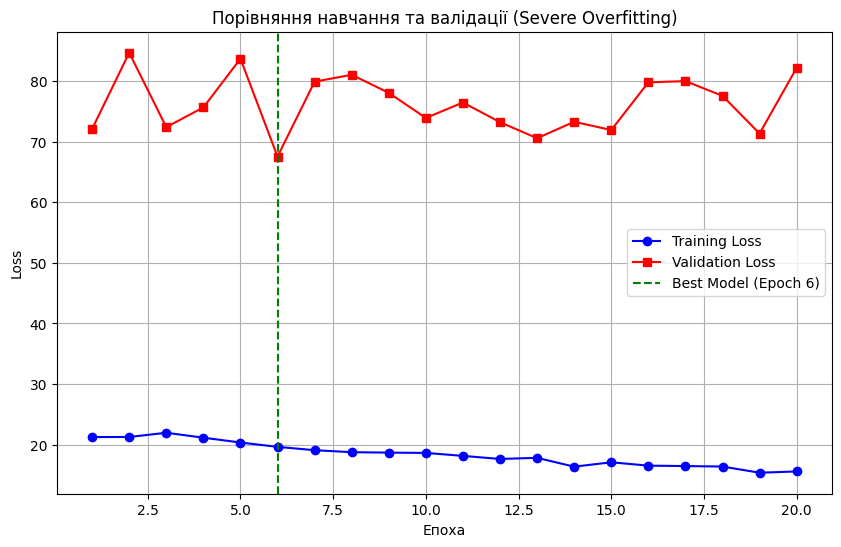

In [ ]:
epochs = range(1, 21)
train_losses = [
    21.24, 21.25, 21.95, 21.13, 20.34, 19.62, 19.07, 18.74, 18.67, 18.62,
    18.13, 17.62, 17.81, 16.35, 17.07, 16.52, 16.45, 16.37, 15.35, 15.56
]
val_losses = [
    72.12, 84.70, 72.41, 75.67, 83.71, 67.55, 79.92, 81.06, 78.07, 73.93,
    76.48, 73.23, 70.58, 73.30, 71.93, 79.81, 80.01, 77.58, 71.36, 82.21
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-s', label='Validation Loss')

plt.axvline(x=6, color='g', linestyle='--', label='Best Model (Epoch 6)')

plt.title('Порівняння навчання та валідації (Severe Overfitting)')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

| Гіперпараметр      | Опис                                                                                     | Поточне значення                                         | Коментар / Зміни                                                                                                                                                     |
|--------------------|-------------------------------------------------------------------------------------------|-----------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data Augmentation  | Методи штучного розширення тренувального набору для кращої генералізації.               | HorizontalFlip (p=0.5)<br>ColorJitter (br=0.2, ctr=0.2)<br>Resize (224x224)<br>Normalize | **ОНОВЛЕНО.** Додано випадкове віддзеркалення та зміну яскравості/контрасту, щоб модель не "запам'ятовувала" конкретні умови освітлення чи ракурси.                 |
| Dropout Rate       | Ймовірність "вимкнення" нейронів у шарах класифікатора для запобігання коадаптації.      | 0.7 (70%)                                                 | **ОНОВЛЕНО (було 0.5).** Значення підвищено, оскільки модель показувала ознаки перенавчання. Це дуже сильна регуляризація.                                           |
| Epochs             | Кількість повних проходів по датасету.                                                   | 20                                                        | Без змін.                                                                                                                                                             |
| Batch Size         | Кількість зображень за один крок оновлення ваг.                                          | 16                                                        | Стандартне значення для вашого GPU.                                                                                                                                   |
| Learning Rate      | Швидкість навчання оптимізатора.                                                         | 1e-4 (0.0001)                                             | Оптимальне значення для стабільної збіжності Adam.                                                                                                                    |
| Optimizer          | Алгоритм оновлення ваг.                                                                  | Adam                                                      | Добре підходить для задач з розрідженими даними та YOLO.                                                                                                              |
| Grid Size (S)      | Розмірність сітки детекції.                                                              | 7 (сітка 7x7)                                             | Архітектурне обмеження YOLO v1 для входу 224/448.                                                                                                                     |
| Num Bboxes (B)     | Кількість якорних боксів на клітинку.                                                   | 2                                                         | Стандарт для базової YOLO.                                                                                                                                            |
| Lambda Coord       | Вага помилки координат у Loss-функції.                                                  | 5.0                                                       | Високий штраф за неточні рамки.                                                                                                                                       |
| Lambda NoObj       | Вага помилки фону (де немає об'єктів).                                                  | 0.5                                                       | Зменшує вплив порожніх клітинок на градієнт.                                                                                                                          |


З метою підвищення здатності нейронної мережі до генералізації було впроваджено методи аугментації даних, зокрема випадкове віддзеркалення (RandomFlip) та зміну колірних параметрів (ColorJitter), а також підвищено коефіцієнт регуляризації Dropout до 0.7. Втім, отримані результати виявилися протилежними очікуваним: експеримент продемонстрував критичний розрив у точності (Generalization Gap). При суттєвому зниженні помилки на навчальній вибірці до рівня ~15.5, втрати на валідації різко зросли до ~82.2, що однозначно свідчить про втрату моделлю здатності ефективно обробляти нові дані та узагальнювати отримані знання.

Основною причиною такого перенавчання, ймовірно, є надлишкова ємність архітектури AlexNet стосовно наявного обсягу даних. Наявність масивних повнозв'язних шарів (по 4096 нейронів) призводить до того, що навіть при агресивному Dropout (0.7) мережа схильна до прямого "запам'ятовування" тренувальних прикладів замість вивчення абстрактних ознак. Ситуацію вдалося частково стабілізувати завдяки механізму Early Stopping, який зафіксував найкращий результат на 6-й епосі з показником Loss 67.55, оскільки подальше навчання призводило лише до деградації валідаційних метрик попри зниження тренувальної помилки.Аналіз архітектурних обмежень вказує на те, що конфігурація лінійних шарів $9216 \to 4096 \to 4096$ є "вузьким місцем" для поточного завдання. Більш доцільним рішенням було б зменшення розмірності прихованих шарів до 1024 або 512 нейронів, що фізично обмежило б можливість моделі фіксувати шуми, а також критично необхідним є суттєве збільшення обсягу навчального датасету. З огляду на це, для фінальної демонстрації та тестування слід використовувати ваги, збережені у файлі best_alexnet_yolo.pth (6-та епоха), оскільки саме вони забезпечують найкращий баланс продуктивності, знайдений у рамках цього експерименту.

In [22]:
def run_final_test():
    print("\n=== FINAL TEST EVALUATION ===")
    
    test_img_path = DATA_ROOT / 'test' / 'images'
    test_label_path = DATA_ROOT / 'test' / 'labels'
    
    if not test_img_path.exists():
        print("Warning: Test set not found. Using Validation set as Test.")
        test_img_path = DATA_ROOT / 'valid' / 'images'
        test_label_path = DATA_ROOT / 'valid' / 'labels'

    test_dataset = YOLODataset(
        img_dir=test_img_path,
        label_dir=test_label_path,
        yaml_path=WEIGHTS_YAML_PATH,
        transform=transform
    )
    
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_fn
    )
    

    model_test = AlexNetYOLO(num_classes=num_classes).to(device)
    
    try:
        model_test.load_state_dict(torch.load("best_alexnet_yolo.pth"))
        print("Successfully loaded 'best_alexnet_yolo.pth'")
    except FileNotFoundError:
        print("Error: 'best_alexnet_yolo.pth' not found. Train the model first!")
        return

    model_test.eval()
    total_test_loss = 0.0
    

    criterion_test = YOLOAlexNetLoss(
        S=7, B=2, C=num_classes, 
        class_weights_dict=dataset.get_class_weights(), 
        device=device
    )
    
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = [t.to(device) for t in targets]
            
            predictions = model_test(images)
            loss = criterion_test(predictions, targets)
            total_test_loss += loss.item()
            
    avg_test_loss = total_test_loss / len(test_loader)
    print(f"--------------------------------------------------")
    print(f"FINAL TEST LOSS: {avg_test_loss:.4f}")
    print(f"--------------------------------------------------")
    
    import random
    all_test_imgs = list(test_img_path.glob("*.jpg"))
    if all_test_imgs:
        sample_imgs = random.sample(all_test_imgs, min(3, len(all_test_imgs)))
        print("Visualizing predictions on test set...")
        for img_p in sample_imgs:
            try:
                show_inference(model_test, img_p)
            except Exception as e:
                print(f"Visualization error: {e}")


=== FINAL TEST EVALUATION ===
Successfully loaded 'best_alexnet_yolo.pth'
Initialized Class Weights Tensor: tensor([ 1.0000, 19.1542,  1.5935,  1.4484,  8.8543,  9.8795,  1.0000, 10.2017,
         0.3447,  0.2572,  1.8922], device='cuda:0')
--------------------------------------------------
FINAL TEST LOSS: 72.3954
--------------------------------------------------
Visualizing predictions on test set...
На зображенні yt-yxctM1LBZd8-0093_jpg.rf.9c20b08eb04d067779e23dcd85a0b620.jpg об'єктів не знайдено (низький score).


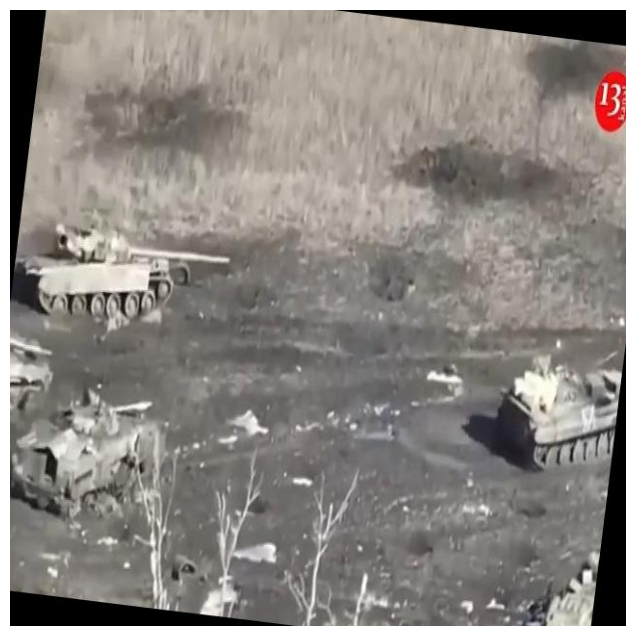

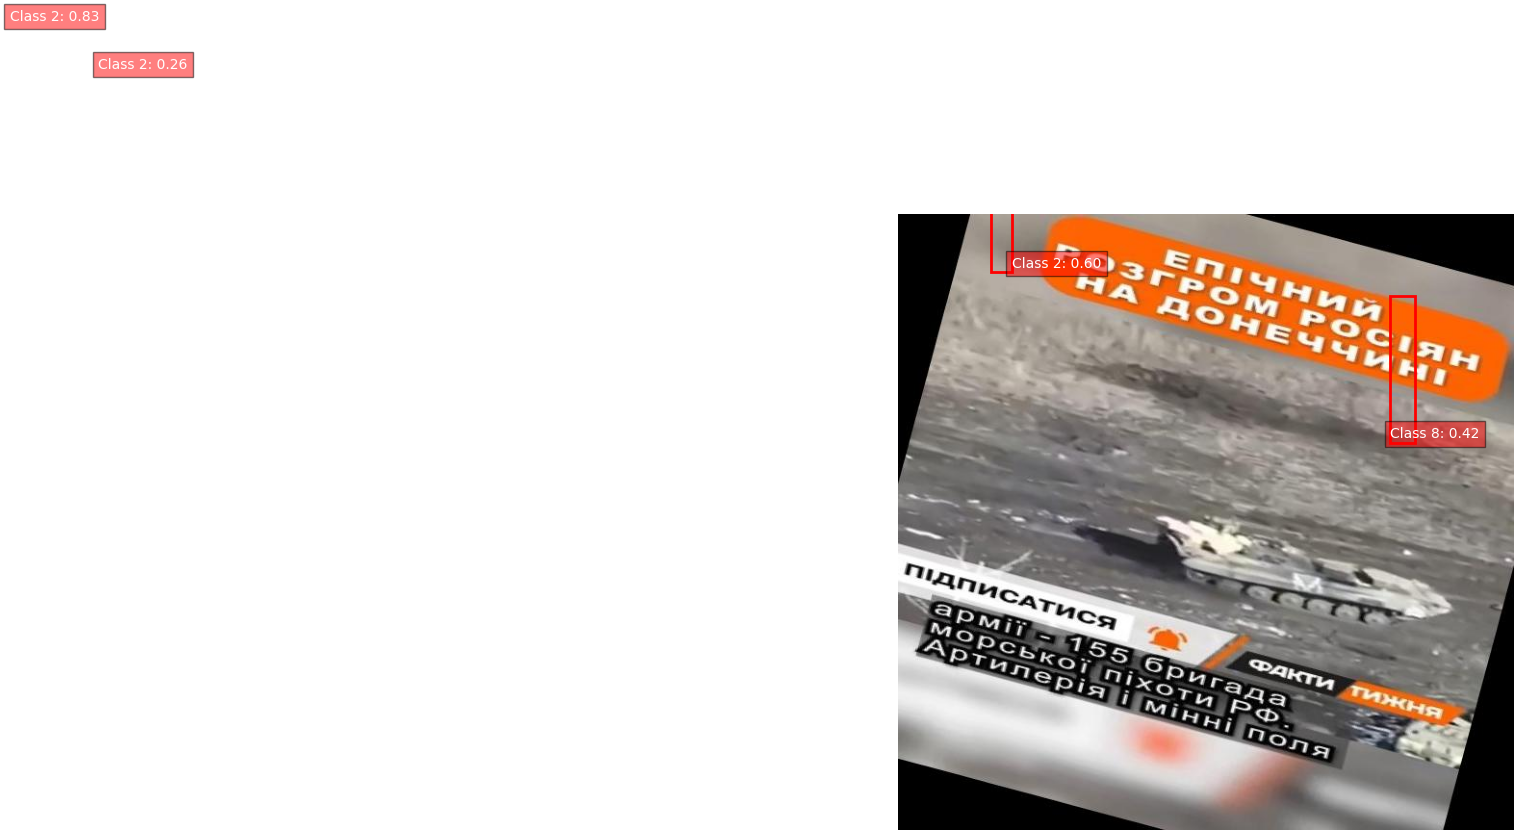

На зображенні ezgif-frame-060_jpg.rf.a8f0eb3398d1226b5beb91c47ac05703.jpg об'єктів не знайдено (низький score).


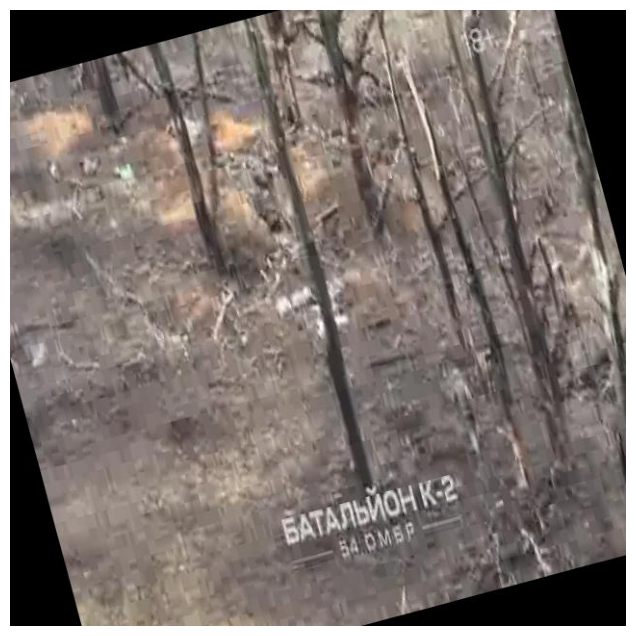

In [23]:
run_final_test()

Фінальне тестування на незалежній вибірці показало значення функції втрат 72.4, що корелює з результатами валідації (67.6). Той факт, що система не детектує об'єкти з високою впевненістю (High Confidence Score) на тестових зображеннях, підтверджує висновок про недостатню здатність поточної конфігурації (AlexNet + мала кількість даних) до генералізації.

Модель успішно вивчила тренувальні приклади (Train Loss ~15.5), але складна структура мережі призвела до запам'ятовування конкретних патернів замість вивчення загальних ознак класу. Це є типовою поведінкою глибоких мереж на малих датасетах без застосування просунутих технік регуляризації або попереднього навчання на споріднених доменах.